In [ ]:
#handle all imports

import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


# TELCO CUSTOMER CHURN ANALYSIS 

## EXECUTIVE SUMMARY

- Dataset: 7,032 telecom customers, 26.6% churn rate
- Best Model: Random Forest (76% accuracy, 71% recall)
- Key Finding: 88.6% of churn from month-to-month contracts
- Primary Recommendation: Contract conversion campaign

## Data Loading & Understanding

In [13]:
#loading the data
df_customer_data = pd.read_csv(r'WA_Fn-UseC_-Telco-Customer-Churn 2.csv')

In [ ]:
#view the datas first 20 rows
df_customer_data.head(20)

'''
    gender, SeniorCitizen, Partner, Dependents: Customer demographic information 
    Tenure: How long customer has been with the company in months
    Phone service, MultipleLines: Whether or not customer has a phone service and whether that customers phone services have multiple lines(contracts)
    InternetServie: What kind of internet customer subcribed to
    OnlineSecurity, DeviceProtection, TechSupport, StreamingTV, StreamingMovies: Whether customer subscribed to particular service or not
    Contract: Duration of contract customer is on
    PaperlessBilling, PaymentMethod: Billing information
    MonthlyCharges: Subscription cost
    TotalCharges: How much the customer has been charged since start of tenure
    Churn (Target variable ): Whether or not customer has stopped doing business with the company or they are an active customer. No means active.
'''

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
#distribution of numerical columns
df_customer_data.describe()

#based on the mean values for tenure MonthlyCharges and TotalCharges the unit for tenure is months

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
#check datatypes 
df_customer_data.info()
'''
    - Most of the columns are objects meaning there is a mix of data types that need to be resolved in 
    order to proceed with the data (18 columns are objects)
    - There are no null values in the columns
'''

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


'\n    Most of the columns are objects meaning there is a mix of data types that need to be resolved in \n    order to proceed with the data\n'

### Looking into a few Multi-Class Encoding columns

In [ ]:
df_customer_data['MultipleLines'].value_counts()
#only 3 options using one-hot-encoding

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [ ]:
df_customer_data['InternetService'].value_counts()
#only 3 options using one-hot-encoding

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [ ]:
df_customer_data['Contract'].value_counts()
#only 3 options using one-hot-encoding

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [ ]:

df_customer_data['PaymentMethod'].value_counts()
#only 4 options using one-hot-encoding

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

## Data Cleaining

- deleted customerID since each value is unique and won't benefit the model training
- changed all datatypes from object to string or numerical
- dropped the 11 TotalCharges that were NaN rows since 11/7000 is negligable portion of dataset and safe to drop

In [24]:
#deleting customer id because each row is unique and is of no use for the model training
df_customer_data.drop('customerID', axis=1, inplace=True)

In [46]:
#converting all text columns to string before encoding since they are object dtypes

columns_to_change = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'OnlineBackup']
df_customer_data[columns_to_change] = df_customer_data[columns_to_change].astype('string')

In [47]:
#make totalCharges numerical

df_customer_data['TotalCharges'] = pd.to_numeric(df_customer_data['TotalCharges'], errors='coerce')

print(df_customer_data['TotalCharges'].isna().sum())  # Check if there are any NaN values

#there are 11 NaN values to be taken care of

0


In [83]:
#dropping NaN TotalCharges Rows from Total charges since 11/7k is safe to drop

df_customer_data.dropna(subset=['TotalCharges'], inplace=True)

#reset the index since I dropped the rows
df_customer_data.reset_index(drop=True, inplace=True)

In [84]:
#final cleaned version with human-readable labels
df_cleaned = df_customer_data

In [86]:
# Getting the non-numerical columns
non_numeric_cols = df_cleaned.select_dtypes(exclude=['number']).columns

# Printing the value counts for each non-numerical column
for col in non_numeric_cols:
    print(f"Value counts for {col}:")
    print(df_cleaned[col].value_counts())
    print("\n")
    
'''
Binary encoding based on value counts: gender, partner, dependents, phoneservice, PaperlessBilling
Multi-class encoding: MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaymentMethod
'''

Value counts for gender:
gender
Male      3549
Female    3483
Name: count, dtype: Int64


Value counts for Partner:
Partner
No     3639
Yes    3393
Name: count, dtype: Int64


Value counts for Dependents:
Dependents
No     4933
Yes    2099
Name: count, dtype: Int64


Value counts for PhoneService:
PhoneService
Yes    6352
No      680
Name: count, dtype: Int64


Value counts for MultipleLines:
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: Int64


Value counts for InternetService:
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: Int64


Value counts for OnlineSecurity:
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: Int64


Value counts for OnlineBackup:
OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: Int64


Value counts for DeviceProtection

'\nBinary encoding based on value counts: gender, partner, dependents, phoneservice, PaperlessBilling\nMulti-class encoding: MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaymentMethod\n'

In [100]:
#Encoding columns

# Binary encoding columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
le = LabelEncoder()

df_encoding = pd.DataFrame(index=df_cleaned.index)
for col in binary_cols:
    df_encoding[col + '_encoded'] = le.fit_transform(df_cleaned[col]).astype('int64')

# Multi-class encoding columns (using one-hot encoding)
multi_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
for col in multi_cols:
    if col == 'gender':
        dummies = pd.get_dummies(df_cleaned[col], prefix=col, drop_first=True)
    else:
        dummies = pd.get_dummies(df_cleaned[col], prefix=col)
    df_encoding = pd.concat([df_encoding, dummies], axis=1)
    
# Add the numerical features to df_encoding
numerical_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
df_encoding[numerical_cols] = df_cleaned[numerical_cols]
    
# Encoding the target variable (Churn)
churn_encoded = le.fit_transform(df_cleaned['Churn'])
df_encoding['Churn_encoded'] = churn_encoded

In [101]:
df_encoding.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Partner_encoded                          7032 non-null   int64  
 1   Dependents_encoded                       7032 non-null   int64  
 2   PhoneService_encoded                     7032 non-null   int64  
 3   PaperlessBilling_encoded                 7032 non-null   int64  
 4   gender_Male                              7032 non-null   boolean
 5   MultipleLines_No                         7032 non-null   boolean
 6   MultipleLines_No phone service           7032 non-null   boolean
 7   MultipleLines_Yes                        7032 non-null   boolean
 8   InternetService_DSL                      7032 non-null   boolean
 9   InternetService_Fiber optic              7032 non-null   boolean
 10  InternetService_No                       7032 no

## EDA 

Visuals for the following: 
1. churn rate
2. distribution of key features
3. correlation heatmap
4. Top correlations for churn

### Insights
1. Customer churn is 26.6% of the customers


Top correlations with customer churn:
    1. the biggest predictor is whether they are on a month to month contract so this means customers most likely won't stay if they are on month-to-month. Which makes sense because they can cancel anytime so they will just use when the need it and there is no incentive to stay really.
    2. after that is not having onlinesecurity so this is interesting because it means the customers that use the security services are more impressed and find value in the company enough to stay.
    3. then not having tech support so this one also makes a lot of sense the customers with tech support will have a more pleasant experience and so the attrition of those customers will be less

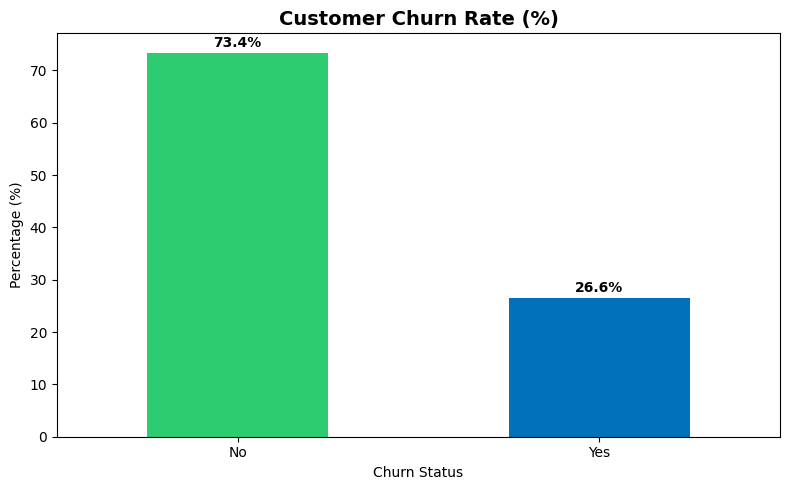

In [107]:
# Churn Rate Viz
fig, ax = plt.subplots(figsize=(8, 5))
churn_counts = df_cleaned['Churn'].value_counts()
churn_pct = (churn_counts / churn_counts.sum()) * 100
churn_pct.plot(kind='bar', ax=ax, color=['#2ecc71', '#0071BA'])
ax.set_title('Customer Churn Rate (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn Status')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(churn_pct):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

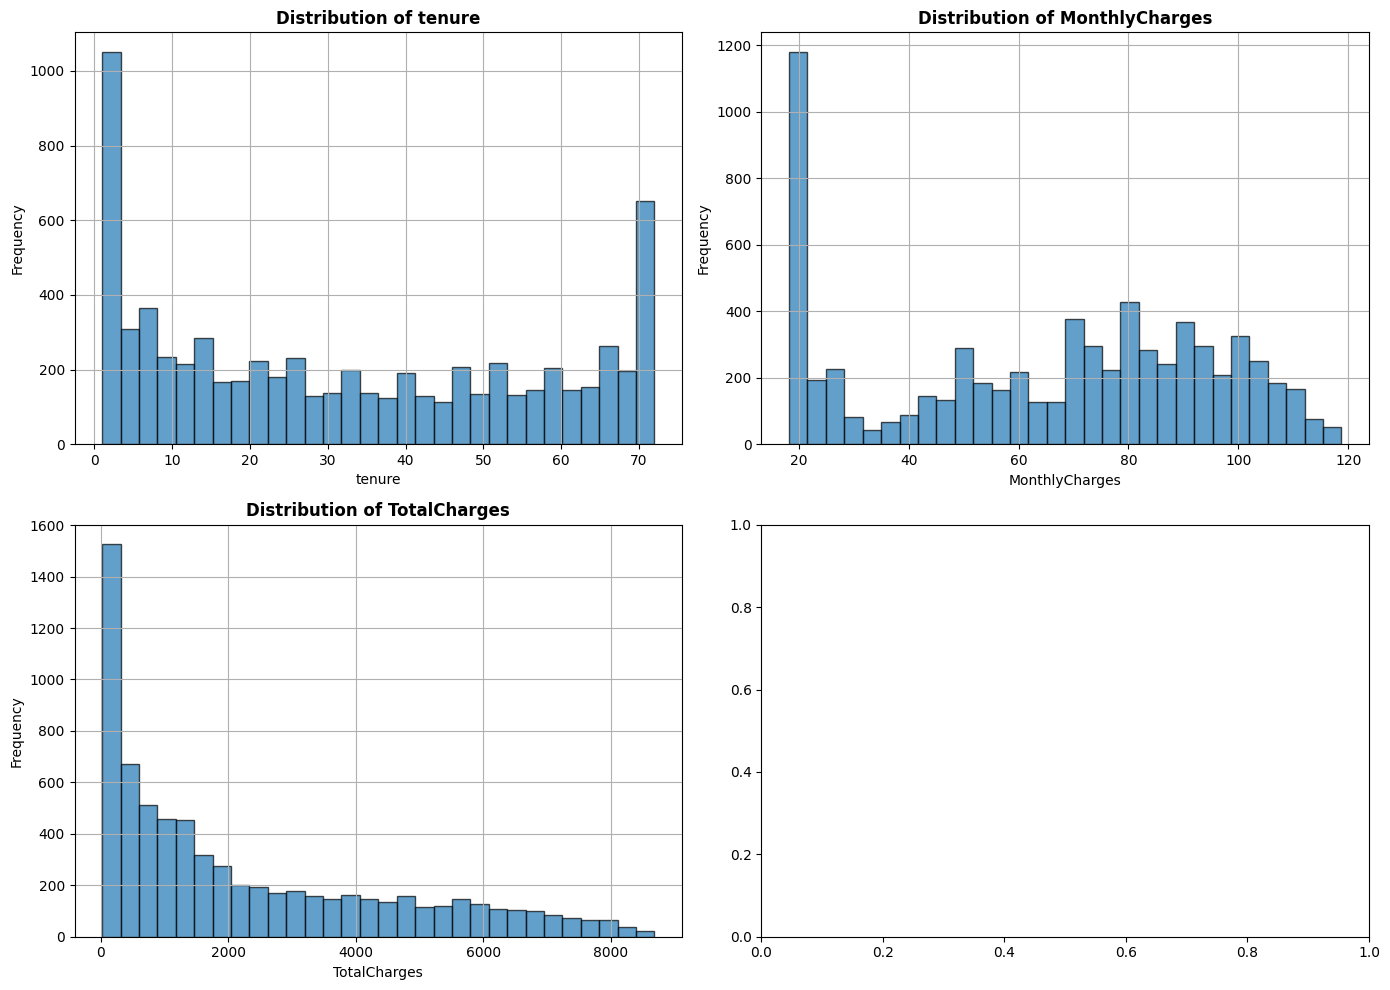

In [112]:
# Distribution of Key Numerical Features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
key_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for idx, col in enumerate(key_features):
    ax = axes[idx // 2, idx % 2]
    df_cleaned[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


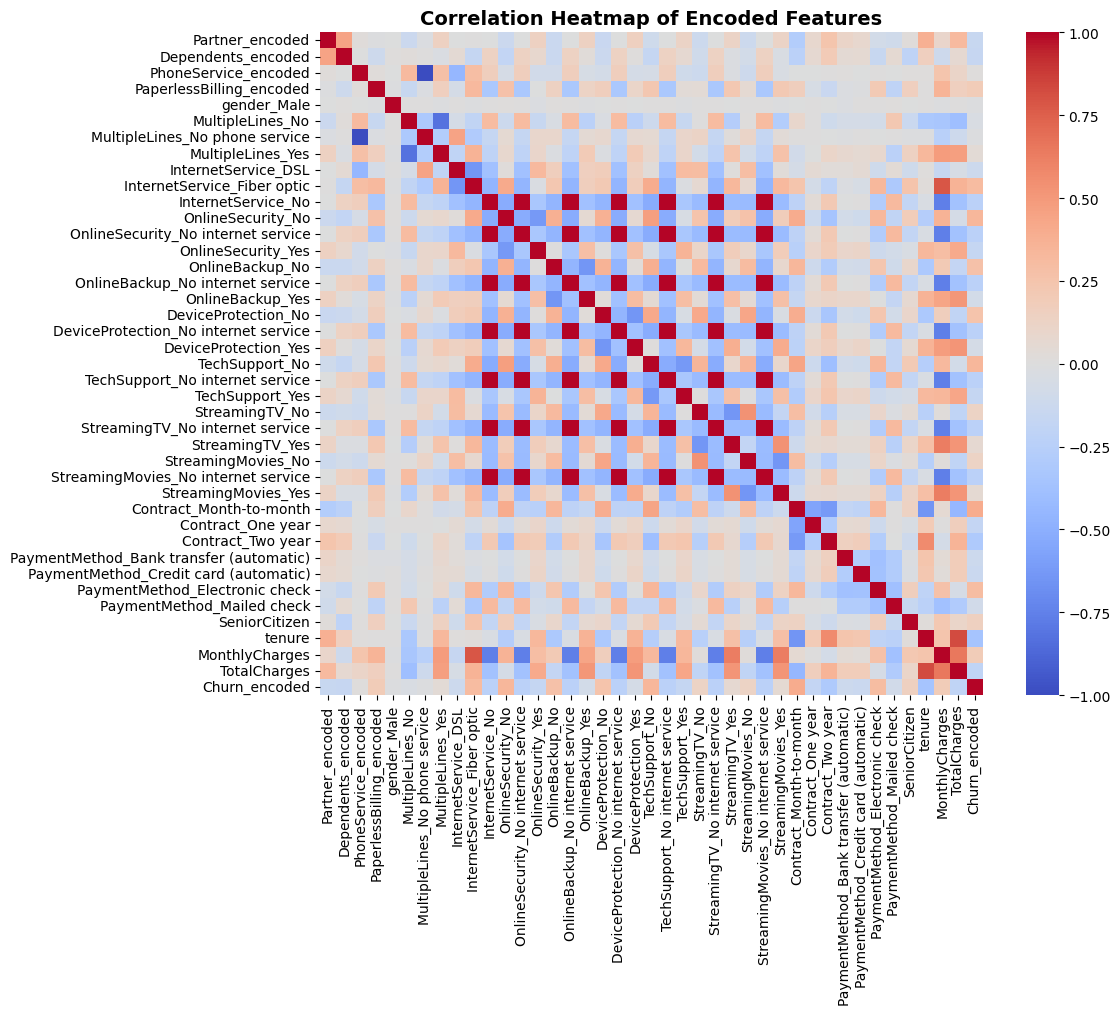

In [109]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
correlation_matrix = df_encoding.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Heatmap of Encoded Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


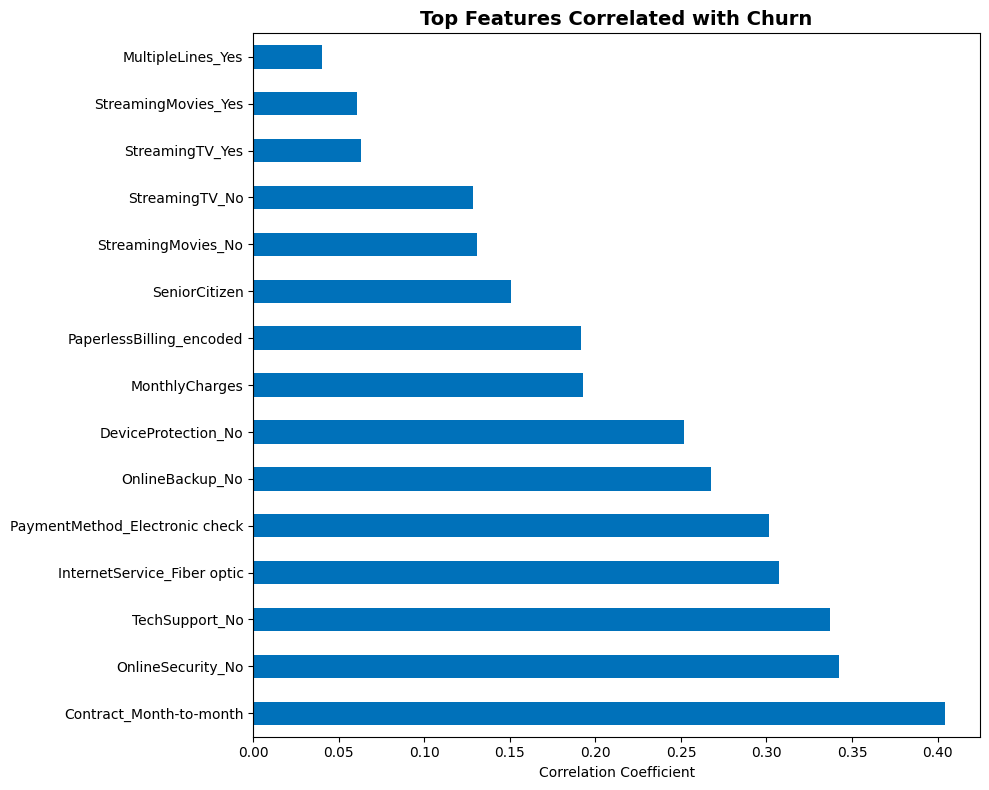

In [114]:
# Top Correlations with Churn
churn_corr = df_encoding.corr()['Churn_encoded'].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
churn_corr[1:16].plot(kind='barh', ax=ax, color=['#e74c3c' if x < 0 else '#0071BA' for x in churn_corr[1:16]])
ax.set_title('Top Features Correlated with Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

## Feature Engineering

Note: I intentionally did it after encoding for model training purposes

Creating 3 new features:

1. avg_usage_per_month: Captures historical customer value. (TotalCharges / tenure)
    - a more stable metric to measure spending value of customers that is not as affected by impulse subscriptions 

2. engagement_score: Captures how invested the customer is in the ecosystem. (Sum of _Yes service columns)
    
3. monthly_charge_variance: Captures billing volatility and potential payment shock. (MonthlyCharges - avg_usage_per_month)
    - if a customer has a high variance then they are more volatile at present compared to a customer with a low variance

In [118]:
# Feature Engineering

# 1. Average usage per month (historical customer value)
df_encoding['avg_usage_per_month'] = df_encoding['TotalCharges'] / df_encoding['tenure']

# Handle division by zero (if tenure is 0)
df_encoding['avg_usage_per_month'] = df_encoding['avg_usage_per_month'].replace([np.inf, -np.inf], 0)


# 2. Engagement score (sum of all service subscriptions)
service_cols = [col for col in df_encoding.columns if col.endswith('_Yes')]
df_encoding['engagement_score'] = df_encoding[service_cols].sum(axis=1)


# 3. Monthly charge variance (billing volatility)
df_encoding['monthly_charge_variance'] = df_encoding['MonthlyCharges'] - df_encoding['avg_usage_per_month']

In [119]:
#Show preview of engineered features
print(df_encoding[['avg_usage_per_month', 'engagement_score', 'monthly_charge_variance']].head(10))

   avg_usage_per_month  engagement_score  monthly_charge_variance
0            29.850000                 1                 0.000000
1            55.573529                 2                 1.376471
2            54.075000                 2                -0.225000
3            40.905556                 3                 1.394444
4            75.825000                 0                -5.125000
5           102.562500                 4                -2.912500
6            88.609091                 3                 0.490909
7            30.190000                 1                -0.440000
8           108.787500                 5                -3.987500
9            56.257258                 2                -0.107258


## Model Training & Evaluation

In [ ]:
# Preparing the features and the target 
y = df_encoding['Churn_encoded']
X = df_encoding.drop('Churn_encoded', axis=1)

# Split data: 80:20  (80 train: 20 test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Total features: {X_train.shape[1]}")

Training set size: 5625
Test set size: 1407
Total features: 43


### Train Logistic Regression Model with proper scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42, max_iter=5000, solver='lbfgs')
lr_model.fit(X_train_scaled, y_train)

y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)
y_test_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]


print("LOGISTIC REGRESSION MODEL EVALUATION \n")

train_accuracy = lr_model.score(X_train_scaled, y_train)
print(f"\nTraining Accuracy: \t{train_accuracy:.4f}")

test_accuracy = lr_model.score(X_test_scaled, y_test)
print(f"Testing Accuracy: \t{test_accuracy:.4f}")

print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))

c_matrix = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(c_matrix)

roc_auc = roc_auc_score(y_test, y_test_pred_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

LOGISTIC REGRESSION MODEL EVALUATION 


Training Accuracy: 	0.8084
Testing Accuracy: 	0.7875

Classification Report on Test Set:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Confusion Matrix:
[[915 118]
 [181 193]]

ROC-AUC Score: 0.8316


## Train Random Forest Model

In [132]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train_scaled, y_train)
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)
y_test_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]


print("RANDOM FOREST MODEL EVALUATION \n")

train_accuracy_rf = rf_model.score(X_train_scaled, y_train)
print(f"\nTraining Accuracy: \t{train_accuracy_rf:.4f}")

# Testing Accuracy
test_accuracy_rf = rf_model.score(X_test_scaled, y_test)
print(f"Testing Accuracy: \t{test_accuracy_rf:.4f}")

# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_rf, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
print("\nConfusion Matrix:")
print(cm_rf)

# ROC-AUC Score
roc_auc_rf = roc_auc_score(y_test, y_test_pred_proba_rf)
print(f"\nROC-AUC Score: {roc_auc_rf:.4f}")

RANDOM FOREST MODEL EVALUATION 


Training Accuracy: 	0.8567
Testing Accuracy: 	0.7576

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.88      0.77      0.82      1033
       Churn       0.53      0.71      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407


Confusion Matrix:
[[800 233]
 [108 266]]

ROC-AUC Score: 0.8292


## Analysis and Insights

## Final Model Recommendation: Random Forest

### Executive Summary:

For predicting customer churn, I recommend using the Random Forest model. Both the Logistic Regression and Random Forest models showed strong predictive capabilities, but Random Forest aligns better with our main goal: reducing customer loss in a competitive market.

### Justification:

The analysis highlighted a trade-off between the two models. The crucial question is about the type of error we’re willing to live with.

Focusing on Retaining Customers over Wasted Efforts: 
The Random Forest model works better as a comprehensive tool. It identified 71% of customers who actually churned (Recall), which is a big jump from the 52% identified by the Logistic Regression model. In an industry, where bringing in new customers is much pricier than keeping the ones we already have due to competition, failing to spot a customer at risk is costlier than mistakenly targeting a loyal customer for retention.

Understanding the Trade-Off: 
We know that trying to catch more at-risk customers will lead to less precise predictions. The precision of the Random Forest model was 53%, while the Logistic Regression came in at 62%. This means we’re consciously accepting a higher number of false alarms to achieve our main goal of identifying more true churners.

Prioritizing the Right Metric: 
Although the Logistic Regression model had slightly better overall accuracy and ROC-AUC scores, these figures matter less than recall for our specific issue. It’s not just about being right most of the time; it’s about effectively spotting that smaller group of customers who are ready to leave.

To sum it up, the Random Forest model's better capability to identify and flag customers at risk makes it the most effective tool for enhancing our customer retention strategy.

## Feature Importance 

TOP 15 FEATURE IMPORTANCES

                       feature  importance
       Contract_Month-to-month    0.121993
                  TotalCharges    0.103691
                        tenure    0.101024
                MonthlyCharges    0.064978
           avg_usage_per_month    0.064075
             Contract_Two year    0.057495
   InternetService_Fiber optic    0.054402
       monthly_charge_variance    0.049752
             OnlineSecurity_No    0.044767
PaymentMethod_Electronic check    0.037431
                TechSupport_No    0.037351
             Contract_One year    0.019722
              engagement_score    0.016281
               TechSupport_Yes    0.012741
            OnlineSecurity_Yes    0.012687


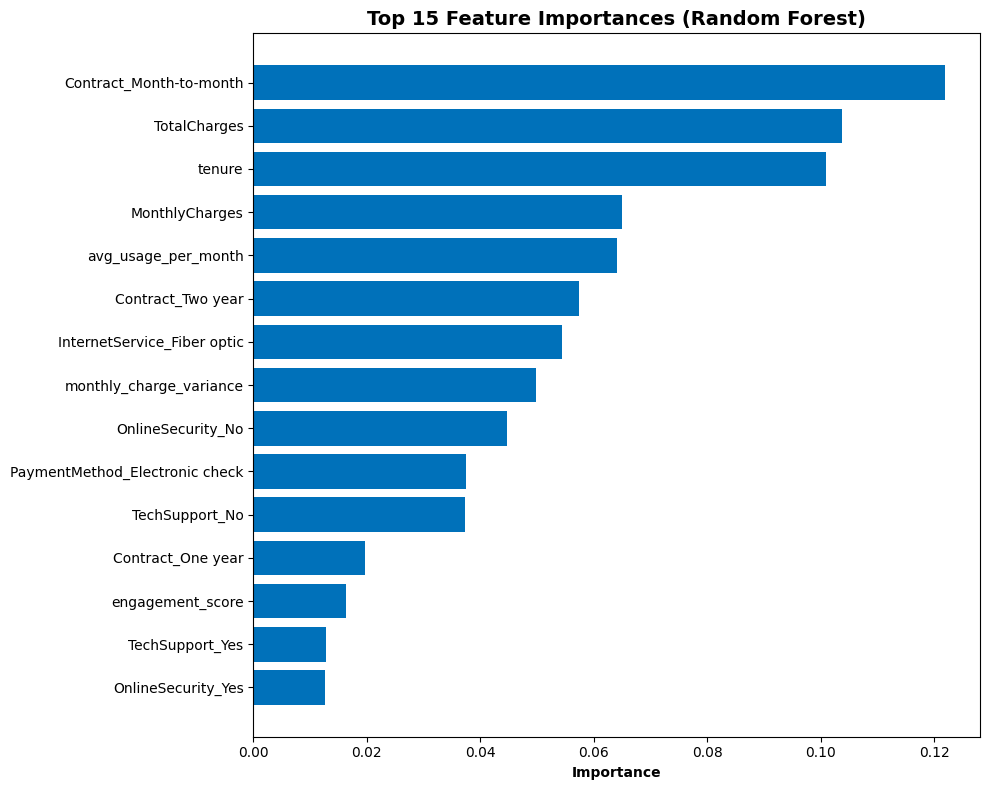

In [134]:
print("TOP 15 FEATURE IMPORTANCES\n")

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(15).to_string(index=False))

# Visualize 
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(15)
ax.barh(top_features['feature'], top_features['importance'], color='#0071BA')
ax.set_xlabel('Importance', fontweight='bold')
ax.set_title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Top 3 Important Features

1. Month-to-month-Contract
2. Total Charges
3. Tenure

## Further Analysis of important features 

CONTRACT TYPE ANALYSIS: MONTH-TO-MONTH vs LONG-TERM


Contract Type Distribution for Churned Customers:
Contract
Month-to-month    1655
One year           166
Two year            48
Name: count, dtype: Int64

Percentage Distribution:
Contract
Month-to-month    88.55
One year           8.88
Two year           2.57
Name: count, dtype: Float64

Month-to-Month Contracts (Churned): 1655 customers (88.6%)
Long-Term Contracts (Churned): 214 customers (11.4%)


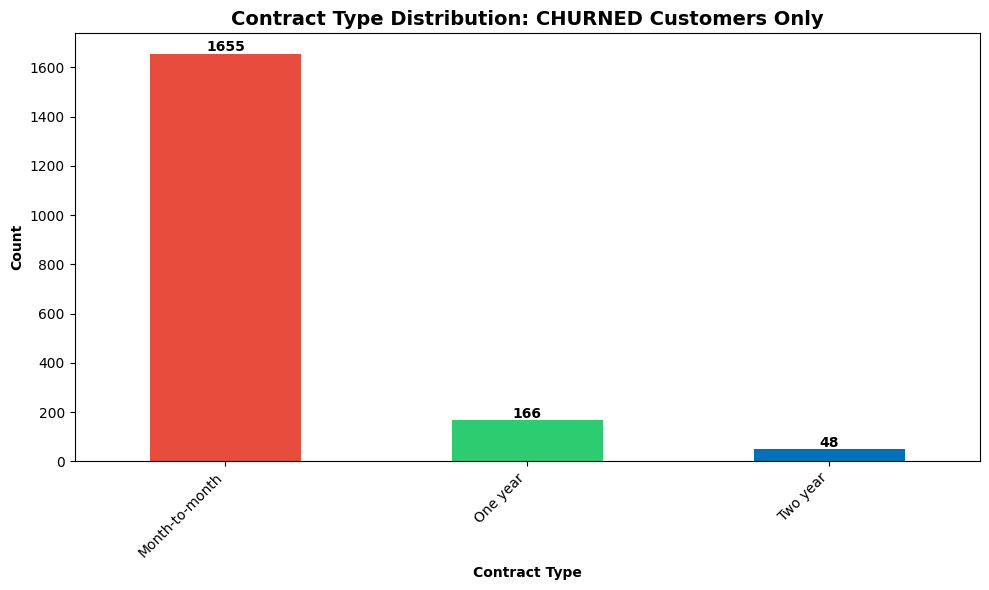

In [146]:
## Contract Type Analysis: What Drives Churn

print("CONTRACT TYPE ANALYSIS: MONTH-TO-MONTH vs LONG-TERM\n")

churn_customers = df_cleaned[df_cleaned['Churn'] == 'Yes']

contract_analysis = churn_customers['Contract'].value_counts()
print("\nContract Type Distribution for Churned Customers:")
print(contract_analysis)
print(f"\nPercentage Distribution:")
print((contract_analysis / contract_analysis.sum() * 100).round(2))

month_to_month = churn_customers[churn_customers['Contract'] == 'Month-to-month']
long_term = churn_customers[~(churn_customers['Contract'] == 'Month-to-month')]

print(f"\nMonth-to-Month Contracts (Churned): {len(month_to_month)} customers ({len(month_to_month)/len(churn_customers)*100:.1f}%)")
print(f"Long-Term Contracts (Churned): {len(long_term)} customers ({len(long_term)/len(churn_customers)*100:.1f}%)")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
contract_counts = churn_customers['Contract'].value_counts()
contract_counts.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71', '#0071BA'])
ax.set_title('Contract Type Distribution: CHURNED Customers Only', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(contract_counts):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

TOTAL CHARGES ANALYSIS: CHURN vs NO CHURN


Total Charges Statistics by Churn Status:
              mean   median    min      max  count
Churn                                             
No     2555.344141  1683.60  18.80  8672.45   5163
Yes    1531.796094   703.55  18.85  8684.80   1869


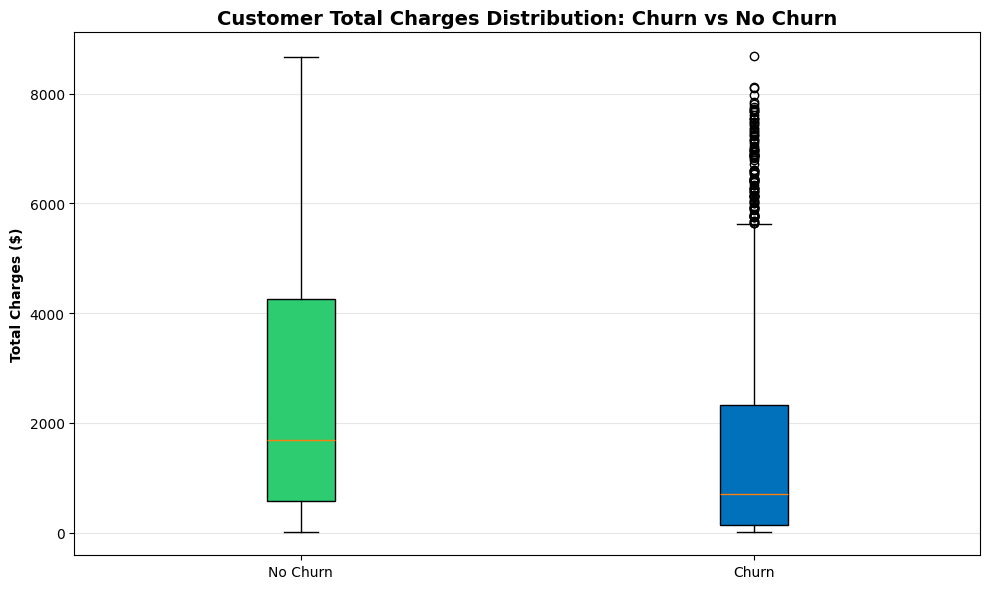

In [141]:
# Total Charges Analysis of Churn vs No Churn Customers

print("TOTAL CHARGES ANALYSIS: CHURN vs NO CHURN\n")

total_charges_by_churn = df_cleaned.groupby('Churn')['TotalCharges'].agg(['mean', 'median', 'min', 'max', 'count'])
print("\nTotal Charges Statistics by Churn Status:")
print(total_charges_by_churn)

churn_no_charges = df_cleaned[df_cleaned['Churn'] == 'No']['TotalCharges']
churn_yes_charges = df_cleaned[df_cleaned['Churn'] == 'Yes']['TotalCharges']

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
charges_data = [churn_no_charges, churn_yes_charges]
bp = ax.boxplot(charges_data, tick_labels=['No Churn', 'Churn'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#0071BA']):
    patch.set_facecolor(color)
ax.set_ylabel('Total Charges ($)', fontweight='bold')
ax.set_title('Customer Total Charges Distribution: Churn vs No Churn', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

TENURE ANALYSIS: CHURN vs NO CHURN


Tenure Statistics by Churn Status:
            mean  median  min  max  count
Churn                                    
No     37.650010    38.0    1   72   5163
Yes    17.979133    10.0    1   72   1869


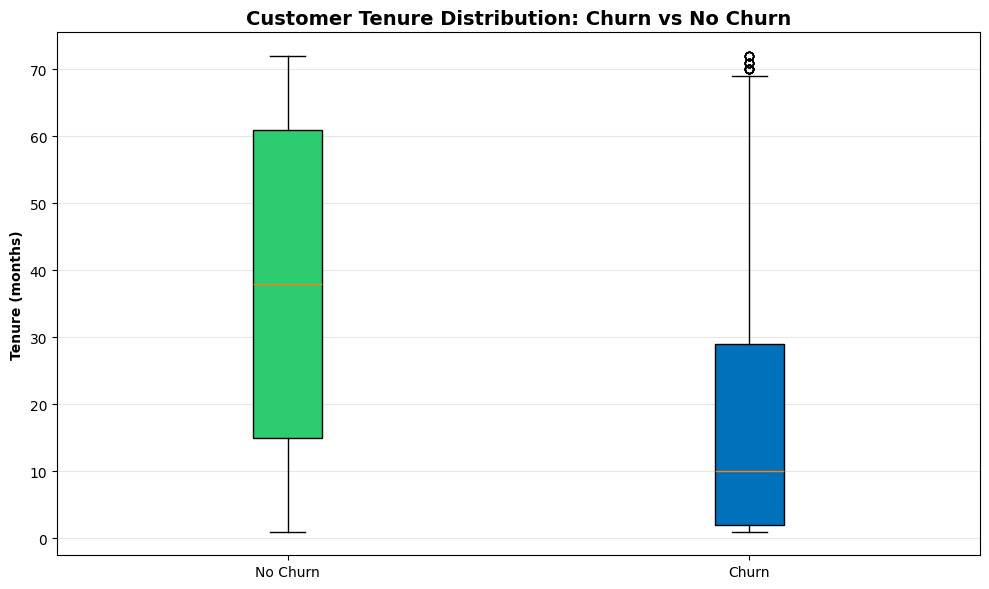

In [142]:
# Average Tenure of Churn vs No Churn Customers

print("TENURE ANALYSIS: CHURN vs NO CHURN\n")

tenure_by_churn = df_cleaned.groupby('Churn')['tenure'].agg(['mean', 'median', 'min', 'max', 'count'])
print("\nTenure Statistics by Churn Status:")
print(tenure_by_churn)

churn_no = df_cleaned[df_cleaned['Churn'] == 'No']['tenure']
churn_yes = df_cleaned[df_cleaned['Churn'] == 'Yes']['tenure']

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
tenure_data = [churn_no, churn_yes]
bp = ax.boxplot(tenure_data, tick_labels=['No Churn', 'Churn'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#0071BA']):
    patch.set_facecolor(color)
ax.set_ylabel('Tenure (months)', fontweight='bold')
ax.set_title('Customer Tenure Distribution: Churn vs No Churn', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Key Insights: Understanding Why Customers Leave

By combining our predictive model with a thorough analysis of customer data, we’ve pinpointed three main factors that drive customer churn. These insights reveal why customers decide to leave and give us a plan to help keep them around.

1. The Biggest Factor: Month-to-Month Contracts

The top reason for customer churn is the type of contract they have. 88.6% of churn comes from customers on month-to-month contracts. This kind of contract makes it easy for customers to walk away whenever since they aren’t tied down. It’s not just a coincidence. This trend is at the heart of the churn issue.

2. The Behavior Factor: Short Customer Tenure and Total Charges

The model shows that customers who end up churning generally have much shorter tenures compared to loyal ones. The average length of time for a churned customer is just about 18 months, while loyal customers stick around for around 38 months. This points to a critical weakness early on. If new customers don’t quickly engage with our services, they’re at a high risk of leaving. The low TotalCharges for this group isn’t causing churn it is more a symptom of their brief tenure.

## Recommendations

Recommendation: A key move for the company would be to kick off a campaign aimed at converting those month-to-month customers to annual or two-year contracts. Trying out incentives like discounts in the first year, bundled services, or exclusive perks for long-term subscribers could help boost customer loyalty and create a more reliable revenue stream.

Recommendation: Introduce a focused "First 90 Days" onboarding program for new customers, especially those with month-to-month contracts. This program should aim to promote the use of essential services early on to show their value and encourage retention from the get-go.